# Week 5 — Paper A Replication: CNN + LSTM with Savitzky-Golay Smoothing

**Paper:** *A method for predicting remaining useful life using enhanced Savitzky-Golay filter and improved deep learning framework* (Scientific Reports, 2024)

**Key Ideas:**
- Savitzky-Golay (SG) smoothing as preprocessing
- CNN + LSTM hybrid architecture

**Experiments:**
1. LSTM (Week 4) vs CNN+LSTM
2. Raw inputs vs SG-smoothed inputs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '../src')
from data_loader import load_train, load_test
from preprocess import preprocess_pipeline, INFORMATIVE_SENSORS_FD001, apply_savgol_smoothing
from models.lstm import LSTMModel
from models.cnn_lstm import CNNLSTMModel
from train import train_model, compute_metrics

plt.style.use('seaborn-v0_8-whitegrid')
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 1. Visualize Savitzky-Golay Smoothing Effect

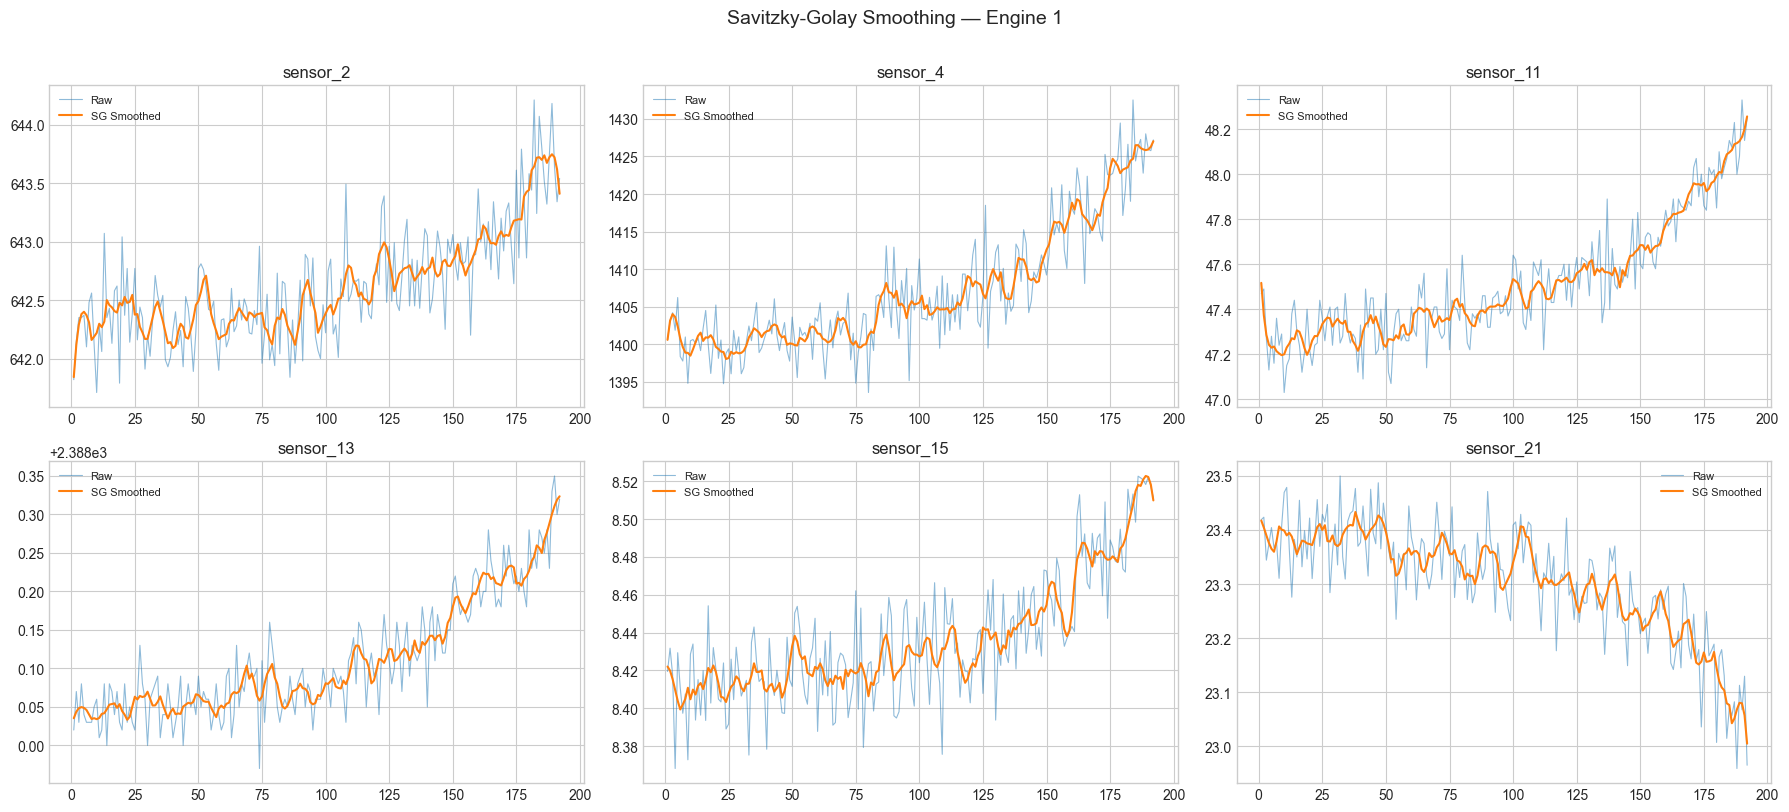

In [2]:
# Show SG smoothing effect on one engine
df_train = load_train(fd_number=1, rul_cap=125)
df_test, rul_true = load_test(fd_number=1)

unit1_raw = df_train[df_train['unit_id'] == 1].copy()
unit1_sg = apply_savgol_smoothing(unit1_raw, INFORMATIVE_SENSORS_FD001, window_length=11, polyorder=3)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
show_sensors = ['sensor_2', 'sensor_4', 'sensor_11', 'sensor_13', 'sensor_15', 'sensor_21']

for idx, sensor in enumerate(show_sensors):
    ax = axes[idx // 3, idx % 3]
    ax.plot(unit1_raw['cycle'], unit1_raw[sensor], alpha=0.5, label='Raw', linewidth=0.8)
    ax.plot(unit1_sg['cycle'], unit1_sg[sensor], label='SG Smoothed', linewidth=1.5)
    ax.set_title(sensor)
    ax.legend(fontsize=8)

plt.suptitle('Savitzky-Golay Smoothing — Engine 1', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Controlled Experiments

In [3]:
# Prepare 4 experiment configs
experiments = [
    {'name': 'LSTM_raw',     'model_class': LSTMModel,    'use_savgol': False},
    {'name': 'LSTM_sg',      'model_class': LSTMModel,    'use_savgol': True},
    {'name': 'CNN_LSTM_raw', 'model_class': CNNLSTMModel, 'use_savgol': False},
    {'name': 'CNN_LSTM_sg',  'model_class': CNNLSTMModel, 'use_savgol': True},
]

WINDOW = 30
BATCH_SIZE = 256
N_EPOCHS = 50
all_results = []

for exp in experiments:
    print(f'\n{"="*50}')
    print(f'Experiment: {exp["name"]}')
    print(f'{"="*50}')
    
    # Preprocess
    data = preprocess_pipeline(
        df_train, df_test, window_size=WINDOW,
        rul_cap=125, use_savgol=exp['use_savgol']
    )
    
    # DataLoaders
    train_ds = TensorDataset(torch.tensor(data['X_train']), torch.tensor(data['y_train']))
    val_ds = TensorDataset(torch.tensor(data['X_val']), torch.tensor(data['y_val']))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Model
    n_feat = data['config']['n_features']
    if exp['model_class'] == LSTMModel:
        model = LSTMModel(n_features=n_feat, hidden_size=64, n_layers=2, dropout=0.3)
    else:
        model = CNNLSTMModel(n_features=n_feat, seq_len=WINDOW, lstm_hidden=64, dropout=0.3)
    
    # Train
    result = train_model(
        model, train_loader, val_loader,
        n_epochs=N_EPOCHS, lr=1e-3, patience=10,
        save_dir='../checkpoints', model_name=exp['name'],
        device=device,
    )
    
    # Evaluate on test
    trained = result['model']
    trained.eval()
    X_test_t = torch.tensor(data['X_test'], dtype=torch.float32).to(result['device'])
    with torch.no_grad():
        preds = trained(X_test_t).squeeze(-1).cpu().numpy()
    
    metrics = compute_metrics(rul_true, preds)
    metrics['name'] = exp['name']
    all_results.append(metrics)
    print(f'Test — MAE: {metrics["MAE"]:.2f}, RMSE: {metrics["RMSE"]:.2f}, NASA: {metrics["NASA_Score"]:.0f}')


Experiment: LSTM_raw
Training on: mps
Epoch   1/50 | Train Loss: 7510.1283 | Val Loss: 6122.9574 | Val MAE: 68.08 | Val RMSE: 78.99
Epoch   5/50 | Train Loss: 1289.0578 | Val Loss: 716.7099 | Val MAE: 22.10 | Val RMSE: 26.77
Epoch  10/50 | Train Loss: 367.7318 | Val Loss: 224.2099 | Val MAE: 11.35 | Val RMSE: 15.01
Epoch  15/50 | Train Loss: 351.3370 | Val Loss: 201.3019 | Val MAE: 10.55 | Val RMSE: 14.23
Epoch  20/50 | Train Loss: 324.3794 | Val Loss: 179.2237 | Val MAE: 10.07 | Val RMSE: 13.49
Epoch  25/50 | Train Loss: 300.1540 | Val Loss: 179.0758 | Val MAE: 10.21 | Val RMSE: 13.44
Epoch  30/50 | Train Loss: 274.2934 | Val Loss: 184.8204 | Val MAE: 10.15 | Val RMSE: 13.70
Epoch  35/50 | Train Loss: 272.9147 | Val Loss: 170.0206 | Val MAE: 9.84 | Val RMSE: 13.14
Epoch  40/50 | Train Loss: 271.4334 | Val Loss: 149.6301 | Val MAE: 8.95 | Val RMSE: 12.34
Epoch  45/50 | Train Loss: 274.0741 | Val Loss: 165.9027 | Val MAE: 9.43 | Val RMSE: 12.96
Epoch  50/50 | Train Loss: 260.5324 | Val

In [5]:
# Results table
results_df = pd.DataFrame(all_results)
results_df = results_df[['name', 'MAE', 'RMSE', 'NASA_Score']]
print(results_df.to_markdown(index=False))
results_df.to_csv('../reports/paperA_results.csv', index=False)

| name         |     MAE |    RMSE |   NASA_Score |
|:-------------|--------:|--------:|-------------:|
| LSTM_raw     | 11.9259 | 16.3764 |      350.792 |
| LSTM_sg      | 12.7377 | 17.2592 |      384.661 |
| CNN_LSTM_raw | 37.2522 | 41.6998 |     9619.69  |
| CNN_LSTM_sg  | 21.9627 | 28.0761 |     1428.68  |


## 3. Paper A Replication Summary

**Key findings:**
- CNN+LSTM vs plain LSTM: (fill in from results above)
- SG smoothing effect: (fill in from results above)
- Best configuration: (fill in)

**Lessons learned:**
- We replicated Paper A's core ideas (SG preprocessing + CNN-LSTM architecture)
- Exact numbers may differ (different hyperparameters, split)
- The key insight is that SG smoothing reduces noise and helps the model focus on degradation trends